In [1]:
import pandas as pd
import numpy as np

In [2]:
dataset=pd.read_csv('data/cardio_dataset.csv').values

In [3]:
data=dataset[:,0:7]
target=dataset[:,7]

In [4]:
from sklearn.preprocessing import MinMaxScaler

target=np.reshape(target, (-1,1))

scaler_data = MinMaxScaler(feature_range=(0,1))
scaler_target = MinMaxScaler()

data_scaled=scaler_data.fit_transform(data)
target_scaled=scaler_target.fit_transform(target)

In [5]:
from sklearn.model_selection import train_test_split

train_data, test_data, train_target, test_target = train_test_split(data_scaled, target_scaled,test_size=0.2,random_state=35)

In [6]:
from keras.models import Sequential
from keras.layers import Dense,Dropout
import numpy as np

model = Sequential()
model.add(Dense(128, input_dim=7, activation='sigmoid',kernel_initializer='normal'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='sigmoid'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='sigmoid'))
model.add(Dense(1, activation='linear'))

model.compile(optimizer='adam',loss='mse',metrics=['mse','mae'])

model.summary()

d:\0.Tutorial & Project\Deeplearning\Day 5\Project\model\env\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,941 (38.83 KB)

 Trainable params: 9,941 (38.83 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
from sklearn.metrics import r2_score
import keras

class CustomCallback(keras.callbacks.Callback): # class name ekt mkk  hari kamathi name ekk danna puluvn #pass karana value eka, keras.callbacks.Callback viya yutui
    
    def on_epoch_end(self,epoch,logs=None):                  #on_epoch_end :hama epoch ekk avasanaye call vena function eka #epoch: epoch number eka
        predicted_result=model.predict(test_data)
        r2=r2_score(test_target,predicted_result)
        print('epoch ',epoch,'- r2 score:',r2)

In [8]:
from keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint('models/model-{epoch:03d}.keras',monitor='val_loss',save_best_only=True,mode='auto')



In [9]:
history=model.fit(train_data,train_target,epochs=200,validation_data=(test_data,test_target),callbacks=[checkpoint,CustomCallback()])
#CustomCallback() : NN eka train vena atare hama epoch ektm passe mkk hari vdk kara ganimt use karai



Epoch 1/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step p - loss: 0.0397 - mae: 0.1518 - mse: 0
epoch  0 - r2 score: 0.02792357305774429
167/167 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0389 - mae: 0.1501 - mse: 0.0389 - val_loss: 0.0225 - val_mae: 0.1163 - val_mse: 0.0225
Epoch 2/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step p - loss: 0.0252 - mae: 0.1217 - mse: 0.0
epoch  1 - r2 score: 0.04079153734112395
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0252 - mae: 0.1215 - mse: 0.0252 - val_loss: 0.0222 - val_mae: 0.1136 - val_mse: 0.0222
Epoch 3/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step p - loss: 0.0235 - mae: 0.1170 - mse: 0.023
epoch  2 - r2 score: 0.06156205046366636
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0235 - mae: 0.1168 - mse: 0.0235 - val_loss: 0.0218 - val_mae: 0.1101 - val_mse: 0.0218
Epoch 4/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step p - loss: 0.0219 - mae: 0.1133 - mse: 0.0
epoch  3 - r2 score: 0.1280875137776718
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss:

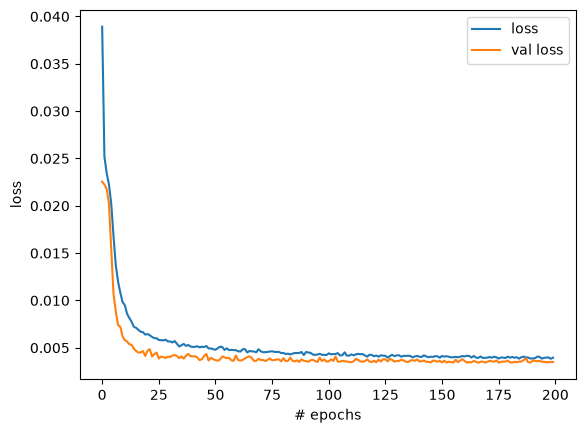

In [10]:
from matplotlib import pyplot as plt

plt.plot(history.history['loss'],label='loss')
plt.plot(history.history['val_loss'],label='val loss')
plt.legend()
plt.xlabel('# epochs')
plt.ylabel('loss')
plt.show()

In [11]:
predicted_result=model.predict(test_data)

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [12]:
print('actual:',test_target[:10].T)
print('predicted:',predicted_result[:10].T)


actual: [[0.07971864 0.10082063 0.010551   0.00468933 0.24853458 0.13950762
  0.07151231 0.22508792 0.3024619  0.14771395]]
predicted: [[0.11729184 0.17128983 0.01812698 0.01631151 0.25378752 0.11152382
  0.10319455 0.24158059 0.28051972 0.19338554]]


In [13]:
print('actual inverse scaled:',scaler_target.inverse_transform(test_target[:10]).T)
print('predicted inverse scaled:',scaler_target.inverse_transform(predicted_result[:10]).T)

actual inverse scaled: [[ 6.9  8.7  1.   0.5 21.3 12.   6.2 19.3 25.9 12.7]]
predicted inverse scaled: [[10.104994  14.711022   1.6462309  1.4913715 21.748075   9.612982
   8.902495  20.706825  24.028332  16.595787 ]]


# Save all the models

In [14]:
import joblib   #skitlearn vla thiyena alogorithms save karaganna thiyena library ekk

joblib.dump(scaler_data,'scaler_data.sav')
joblib.dump(scaler_target,'scaler_target.sav')

['scaler_target.sav']